In [3]:
!pip install -q transformers torch torchvision Pillow


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from torchvision import transforms, models
from torchvision.models import EfficientNet_B3_Weights

from transformers import (
    BertTokenizer,
    BertModel,
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [5]:
CSV_PATH          = r'C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\final_neural_network_data.csv'
TREATMENTS_PATH   = r'C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\skin_disease_dataset2222\treatments.csv'
EFFICIENTNET_CKPT = r'outputs/best_model.pth'
BERT_CKPT_DIR     = r'best_bert_model'
FUSION_SAVE_PATH  = 'fusion_best_model.pth'
RESULTS_DIR       = 'fusion_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

IMG_SIZE   = 300
MAX_LEN    = 256
BATCH_SIZE = 8
EPOCHS     = 15
LR         = 1e-4
BERT_NAME  = 'bert-base-uncased'
TEST_SIZE  = 0.15
VAL_SIZE   = 0.15

In [6]:
print('Loading BLIP model...')
BLIP_NAME      = 'Salesforce/blip-image-captioning-base'
blip_processor = BlipProcessor.from_pretrained(BLIP_NAME)
blip_model     = BlipForConditionalGeneration.from_pretrained(BLIP_NAME).to(DEVICE)
blip_model.eval()
print('BLIP loaded')


def generate_skin_description(image_path, user_description=None):
    img = Image.open(image_path).convert('RGB')

    if user_description and user_description.strip():
        prompt = f'a medical photo showing skin with {user_description.strip()} including'
    else:
        prompt = 'a medical photo showing skin with'

    inputs = blip_processor(
        images=img,
        text=prompt,
        return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = blip_model.generate(
            **inputs,
            max_new_tokens=80,
            num_beams=5,
            min_length=20,
            repetition_penalty=1.3,
            length_penalty=1.2,
        )

    description = blip_processor.decode(output_ids[0], skip_special_tokens=True)
    return description

Loading BLIP model...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP loaded


Auto-generated description:
   a medical photo showing skin with blood all over the face of a baby who had to be attacked by a mosquito


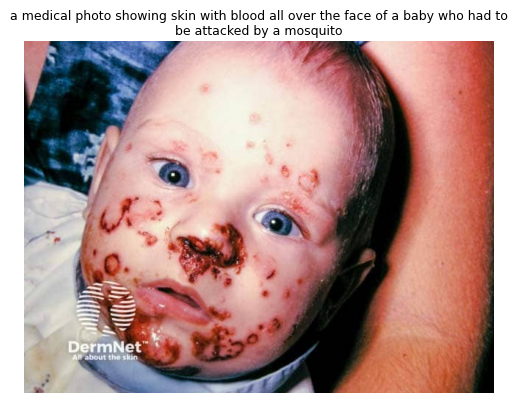

In [7]:
SAMPLE_IMAGE = r'C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\dermnet_dataset\Impetigo\Impetigo_8.jpg'

if os.path.exists(SAMPLE_IMAGE):
    desc = generate_skin_description(SAMPLE_IMAGE)
    print('Auto-generated description:')
    print('  ', desc)

    img = Image.open(SAMPLE_IMAGE).convert('RGB')
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(desc, wrap=True, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Sample image not found, skipping test')

In [8]:
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=['Disease', 'Image_Path'])
df['Disease']    = df['Disease'].str.strip().str.title()
df['Image_Path'] = df['Image_Path'].str.strip()
df = df[df['Image_Path'].apply(os.path.exists)].reset_index(drop=True)

le = LabelEncoder()
df['label'] = le.fit_transform(df['Disease'])
NUM_CLASSES = len(le.classes_)

print('Samples:', len(df))
print('Classes:', list(le.classes_))

Samples: 103
Classes: ['Acne', 'Contact Dermatitis', 'Eczema', 'Impetigo', 'Psoriasis', 'Skin Cancer', 'Vitiligo', 'Warts']


In [9]:
CACHE_PATH = os.path.join(RESULTS_DIR, 'blip_descriptions.csv')

if os.path.exists(CACHE_PATH):
    cache = pd.read_csv(CACHE_PATH)
    df = df.merge(cache[['Image_Path', 'blip_description']], on='Image_Path', how='left')
    missing_mask = df['blip_description'].isna()
    print(f'Loaded {(~missing_mask).sum()} cached descriptions, {missing_mask.sum()} to generate')
else:
    df['blip_description'] = None
    missing_mask = pd.Series([True] * len(df))
    print(f'No cache found, generating {len(df)} descriptions')

to_generate = df[missing_mask].index.tolist()
total = len(to_generate)

for i, idx in enumerate(to_generate):
    df.at[idx, 'blip_description'] = generate_skin_description(df.at[idx, 'Image_Path'])
    if (i + 1) % 10 == 0 or (i + 1) == total:
        print(f'  {i+1}/{total} done')

df[['Image_Path', 'blip_description']].to_csv(CACHE_PATH, index=False)
print('Descriptions saved to cache')
print()
print('Sample descriptions:')
for disease in le.classes_:
    sample = df[df['Disease'] == disease].iloc[0]
    print(f'  [{disease}] {sample["blip_description"]}')

Loaded 103 cached descriptions, 0 to generate
Descriptions saved to cache

Sample descriptions:
  [Acne] a medical photo showing skin with red spots on the side of a woman ' s face, with a white
  [Contact Dermatitis] a medical photo showing skin with red spots on the hands of a patient who has been infected since since since since since since since since since since
  [Eczema] a medical photo showing skin with a man ' s arm and chest, with a red spot on the left
  [Impetigo] a medical photo showing skin with red spots on a baby ' s face, taken from the front seat of a car seat
  [Psoriasis] a medical photo showing skin with red spots on the back of a man ' s back and neck
  [Skin Cancer] a medical photo showing skin with a small red spot on the left side of the skin, and a large white spot on the right side of
  [Vitiligo] a medical photo showing skin with a man ' s face covered in scrubs and shaving hair
  [Warts] a medical photo showing skin with white spots on the fingers of a pati

In [10]:
treatments_df = pd.read_csv(TREATMENTS_PATH, usecols=[0, 1, 7])
treatments_df.columns = ['Disease', 'Treatment', 'Avoid']
treatments_df['Disease'] = treatments_df['Disease'].str.strip().str.title()
treatments_df.dropna(subset=['Disease'], inplace=True)
TREATMENTS = dict(zip(
    treatments_df['Disease'],
    zip(treatments_df['Treatment'], treatments_df['Avoid'])
))
print('Treatments loaded for', len(TREATMENTS), 'diseases')

Treatments loaded for 8 diseases


In [11]:
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, stratify=df['label'], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=train_val_df['label'],
    random_state=SEED
)
print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))

Train: 71 | Val: 16 | Test: 16


In [12]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2),
])

val_img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

tokenizer = BertTokenizer.from_pretrained(BERT_NAME)

In [13]:
class FusionDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len, img_transform):
        self.df            = dataframe.reset_index(drop=True)
        self.tokenizer     = tokenizer
        self.max_len       = max_len
        self.img_transform = img_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row['Image_Path']).convert('RGB')
        img = self.img_transform(img)

        description = str(row['blip_description'])
        enc = self.tokenizer(
            description,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        return {
            'image':          img,
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(int(row['label']), dtype=torch.long),
        }

In [14]:
train_ds = FusionDataset(train_df, tokenizer, MAX_LEN, train_img_transform)
val_ds   = FusionDataset(val_df,   tokenizer, MAX_LEN, val_img_transform)
test_ds  = FusionDataset(test_df,  tokenizer, MAX_LEN, val_img_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready')

DataLoaders ready


In [15]:
class FusionModel(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()

        backbone = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        for p in backbone.parameters():
            p.requires_grad = False
        for block_idx in [5, 6, 7]:
            for p in backbone.features[block_idx].parameters():
                p.requires_grad = True
        self.img_features = backbone.features
        self.img_pool     = backbone.avgpool
        self.img_proj     = nn.Sequential(
            nn.BatchNorm1d(1536),
            nn.Dropout(dropout),
            nn.Linear(1536, 512),
            nn.ReLU(inplace=True),
        )

        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for p in self.bert.parameters():
            p.requires_grad = False
        for p in self.bert.encoder.layer[-4:].parameters():
            p.requires_grad = True
        self.text_proj = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(dropout),
            nn.Linear(768, 512),
            nn.ReLU(inplace=True),
        )

        self.fusion = nn.Sequential(
            nn.BatchNorm1d(1024),
            nn.Dropout(dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, image, input_ids, attention_mask):
        x_img = self.img_features(image)
        x_img = self.img_pool(x_img)
        x_img = torch.flatten(x_img, 1)
        x_img = self.img_proj(x_img)

        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x_txt    = bert_out.last_hidden_state[:, 0, :]
        x_txt    = self.text_proj(x_txt)

        x_fused = torch.cat([x_img, x_txt], dim=1)
        return self.fusion(x_fused)

    def unfreeze_all(self):
        for p in self.img_features.parameters():
            p.requires_grad = True
        for p in self.bert.parameters():
            p.requires_grad = True
        print('All layers unfrozen')

In [16]:
fusion_model = FusionModel(num_classes=NUM_CLASSES).to(DEVICE)

if os.path.exists(EFFICIENTNET_CKPT):
    effi_state = torch.load(EFFICIENTNET_CKPT, map_location=DEVICE)
    img_keys   = {
        k.replace('features.', 'img_features.').replace('pool', 'img_pool'): v
        for k, v in effi_state.items()
        if k.startswith('features') or k.startswith('pool')
    }
    fusion_model.load_state_dict(img_keys, strict=False)
    print('EfficientNet weights loaded')
else:
    print('EfficientNet checkpoint not found — using ImageNet init')

if os.path.exists(BERT_CKPT_DIR):
    pretrained_bert = BertModel.from_pretrained(BERT_CKPT_DIR)
    fusion_model.bert.load_state_dict(pretrained_bert.state_dict(), strict=False)
    print('BERT weights loaded')
else:
    print('BERT checkpoint not found — using bert-base-uncased init')

print('Trainable params:', f'{sum(p.numel() for p in fusion_model.parameters() if p.requires_grad):,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


EfficientNet weights loaded


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: best_bert_model
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT weights loaded
Trainable params: 39,369,686


In [17]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, fusion_model.parameters()),
    lr=LR, weight_decay=1e-4
)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [18]:
def run_epoch(loader, training=True):
    fusion_model.train() if training else fusion_model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        image          = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = fusion_model(image, input_ids, attention_mask)
            loss   = criterion(logits, labels)

        if training:
            loss.backward()
            nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = (np.array(all_preds) == np.array(all_labels)).mean()
    return avg_loss, acc, np.array(all_preds), np.array(all_labels)

In [19]:
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_epoch   = 0
patience     = 5
no_improve   = 0
UNFREEZE_EPOCH = 7
stage2_done  = False

for epoch in range(1, EPOCHS + 1):

    if epoch == UNFREEZE_EPOCH + 1 and not stage2_done:
        fusion_model.unfreeze_all()
        for g in optimizer.param_groups:
            g['lr'] = LR / 10
        stage2_done = True

    tr_loss, tr_acc, _, _ = run_epoch(train_loader, training=True)
    vl_loss, vl_acc, _, _ = run_epoch(val_loader,   training=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    saved = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_epoch   = epoch
        torch.save(fusion_model.state_dict(), FUSION_SAVE_PATH)
        saved = ' -- saved'
        no_improve = 0
    else:
        no_improve += 1

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'Train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
        f'Val loss={vl_loss:.4f} acc={vl_acc:.4f}{saved}'
    )

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'Best epoch: {best_epoch}  val_acc={best_val_acc:.4f}')

Epoch 01/15 | Train loss=2.2564 acc=0.1408 | Val loss=2.0749 acc=0.0625 -- saved
Epoch 02/15 | Train loss=2.3214 acc=0.1268 | Val loss=2.0721 acc=0.1875 -- saved
Epoch 03/15 | Train loss=2.0983 acc=0.2535 | Val loss=2.0562 acc=0.1250
Epoch 04/15 | Train loss=2.0037 acc=0.1690 | Val loss=2.0042 acc=0.1875
Epoch 05/15 | Train loss=1.9668 acc=0.3099 | Val loss=1.9464 acc=0.1875
Epoch 06/15 | Train loss=1.9307 acc=0.3380 | Val loss=1.8371 acc=0.2500 -- saved
Epoch 07/15 | Train loss=1.8158 acc=0.3944 | Val loss=1.7603 acc=0.4375 -- saved
All layers unfrozen
Epoch 08/15 | Train loss=1.8284 acc=0.4225 | Val loss=1.7907 acc=0.5000 -- saved
Epoch 09/15 | Train loss=1.7318 acc=0.3944 | Val loss=1.7440 acc=0.5625 -- saved
Epoch 10/15 | Train loss=1.6552 acc=0.4085 | Val loss=1.7304 acc=0.5000
Epoch 11/15 | Train loss=1.6281 acc=0.4366 | Val loss=1.7251 acc=0.5625
Epoch 12/15 | Train loss=1.6565 acc=0.4507 | Val loss=1.7143 acc=0.5000
Epoch 13/15 | Train loss=1.6022 acc=0.4225 | Val loss=1.7518 a

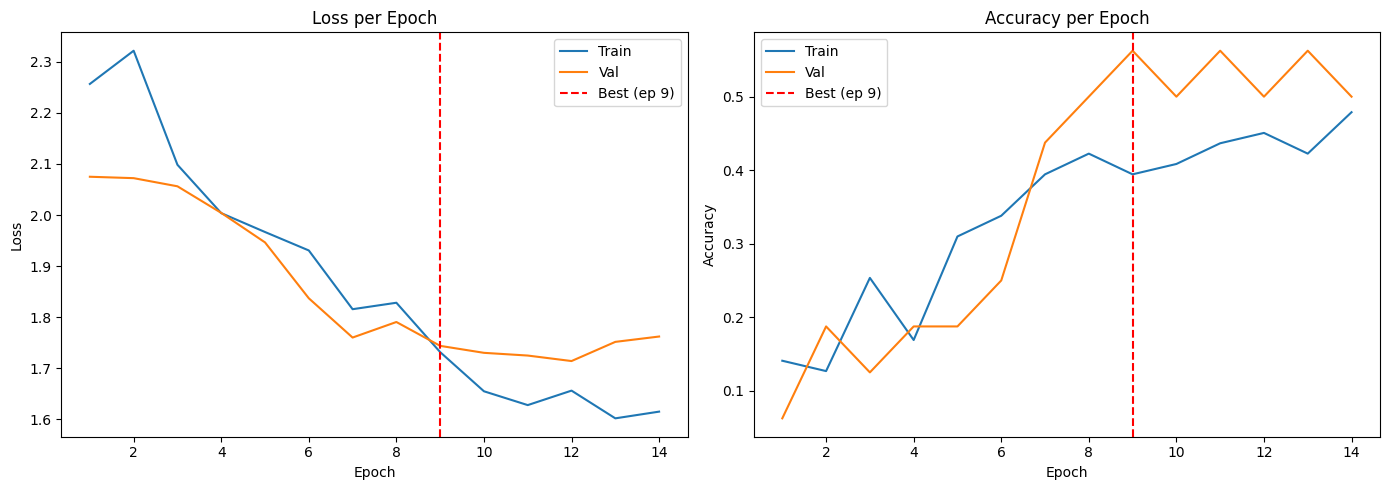

In [20]:
er = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(er, history['train_loss'], label='Train')
axes[0].plot(er, history['val_loss'],   label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best (ep {best_epoch})')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(er, history['train_acc'], label='Train')
axes[1].plot(er, history['val_acc'],   label='Val')
axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Best (ep {best_epoch})')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [21]:
fusion_model.load_state_dict(torch.load(FUSION_SAVE_PATH, map_location=DEVICE))

_, test_acc, test_preds, test_labels = run_epoch(test_loader, training=False)

print('Test Accuracy:', round(test_acc, 4))
print()
print(classification_report(test_labels, test_preds, target_names=le.classes_))

Test Accuracy: 0.5

                    precision    recall  f1-score   support

              Acne       1.00      1.00      1.00         2
Contact Dermatitis       0.00      0.00      0.00         2
            Eczema       0.00      0.00      0.00         2
          Impetigo       1.00      1.00      1.00         2
         Psoriasis       0.50      0.50      0.50         2
       Skin Cancer       0.67      1.00      0.80         2
          Vitiligo       0.33      0.50      0.40         2
             Warts       0.00      0.00      0.00         2

          accuracy                           0.50        16
         macro avg       0.44      0.50      0.46        16
      weighted avg       0.44      0.50      0.46        16



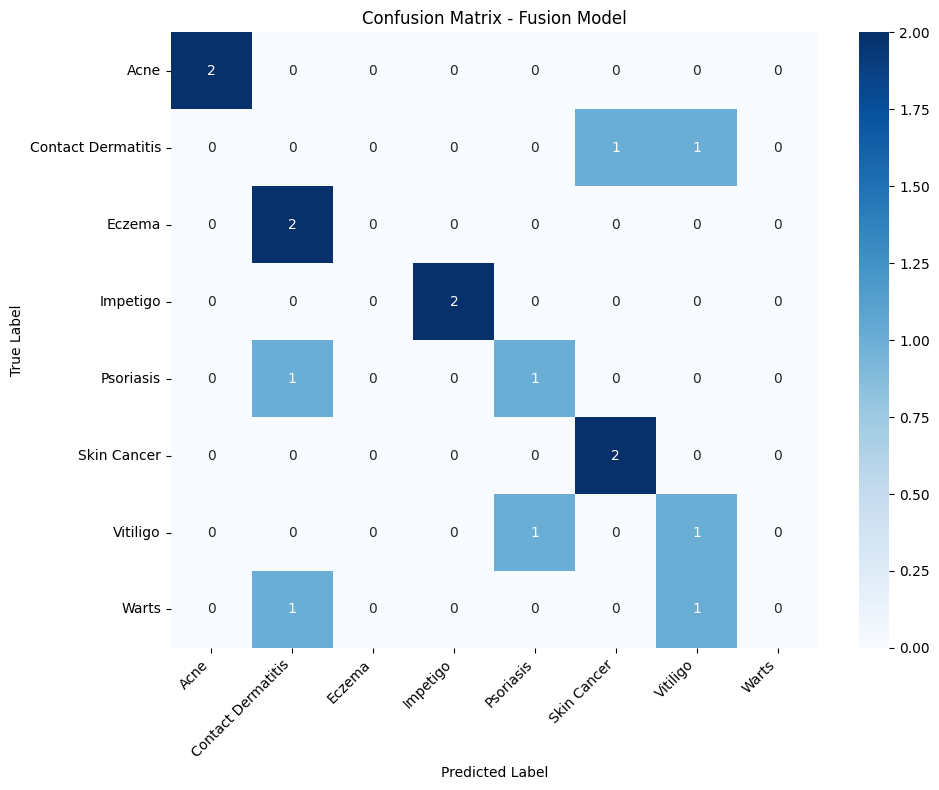

In [22]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix - Fusion Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [23]:
def predict(image_path, user_description=None, top_k=3):
    fusion_model.eval()

    description = generate_skin_description(image_path, user_description)
    print(f'Generated description: {description}')

    img        = Image.open(image_path).convert('RGB')
    img_tensor = val_img_transform(img).unsqueeze(0).to(DEVICE)

    enc = tokenizer(
        description,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits = fusion_model(img_tensor, input_ids, attention_mask)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    top_idx   = np.argsort(probs)[::-1][:top_k]
    top_preds = [
        {'disease': le.classes_[i], 'confidence': round(probs[i] * 100, 2)}
        for i in top_idx
    ]

    best_disease      = top_preds[0]['disease']
    treatment, avoid  = TREATMENTS.get(best_disease, ('Not available', 'Not available'))

    return {
        'description': description,
        'disease':     best_disease,
        'confidence':  top_preds[0]['confidence'],
        'treatment':   str(treatment),
        'avoid':       str(avoid),
        'top_k':       top_preds,
    }

import matplotlib
matplotlib.rcParams['figure.dpi'] = 200
def show_result(image_path, result):
    img = Image.open(image_path).convert('RGB')

    fig, axes = plt.subplots(1, 2, figsize=(28, 14))  # ← أكبر

    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title('Input Image', fontsize=22, fontweight='bold')  # ← أكبر

    import textwrap
    desc_wrapped = '\n'.join(textwrap.wrap(result['description'], width=60))  # ← wrap للنص الطويل

    info = (
        f"Description:\n{desc_wrapped}\n\n"
        f"Disease     : {result['disease']}\n"
        f"Confidence  : {result['confidence']:.2f}%\n\n"
        f"Treatment   : {result['treatment']}\n\n"
        f"Avoid       : {result['avoid']}\n\n"
        f"Top predictions:\n"
    )
    for i, p in enumerate(result['top_k'], 1):
        info += f"  {i}. {p['disease']:<25} {p['confidence']:>6.2f}%\n"

    axes[1].axis('off')
    axes[1].text(
        0.02, 0.98, info,
        transform=axes[1].transAxes,
        fontsize=17,                          # ← أكبر
        verticalalignment='top',
        fontfamily='monospace',
        linespacing=1.6,                      # ← مسافة بين السطور
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8)
    )

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'prediction_result.png'), dpi=200)
    plt.show()

Generated description: a medical photo showing skin with blood all over the face of a baby who had to be attacked by a mosquito


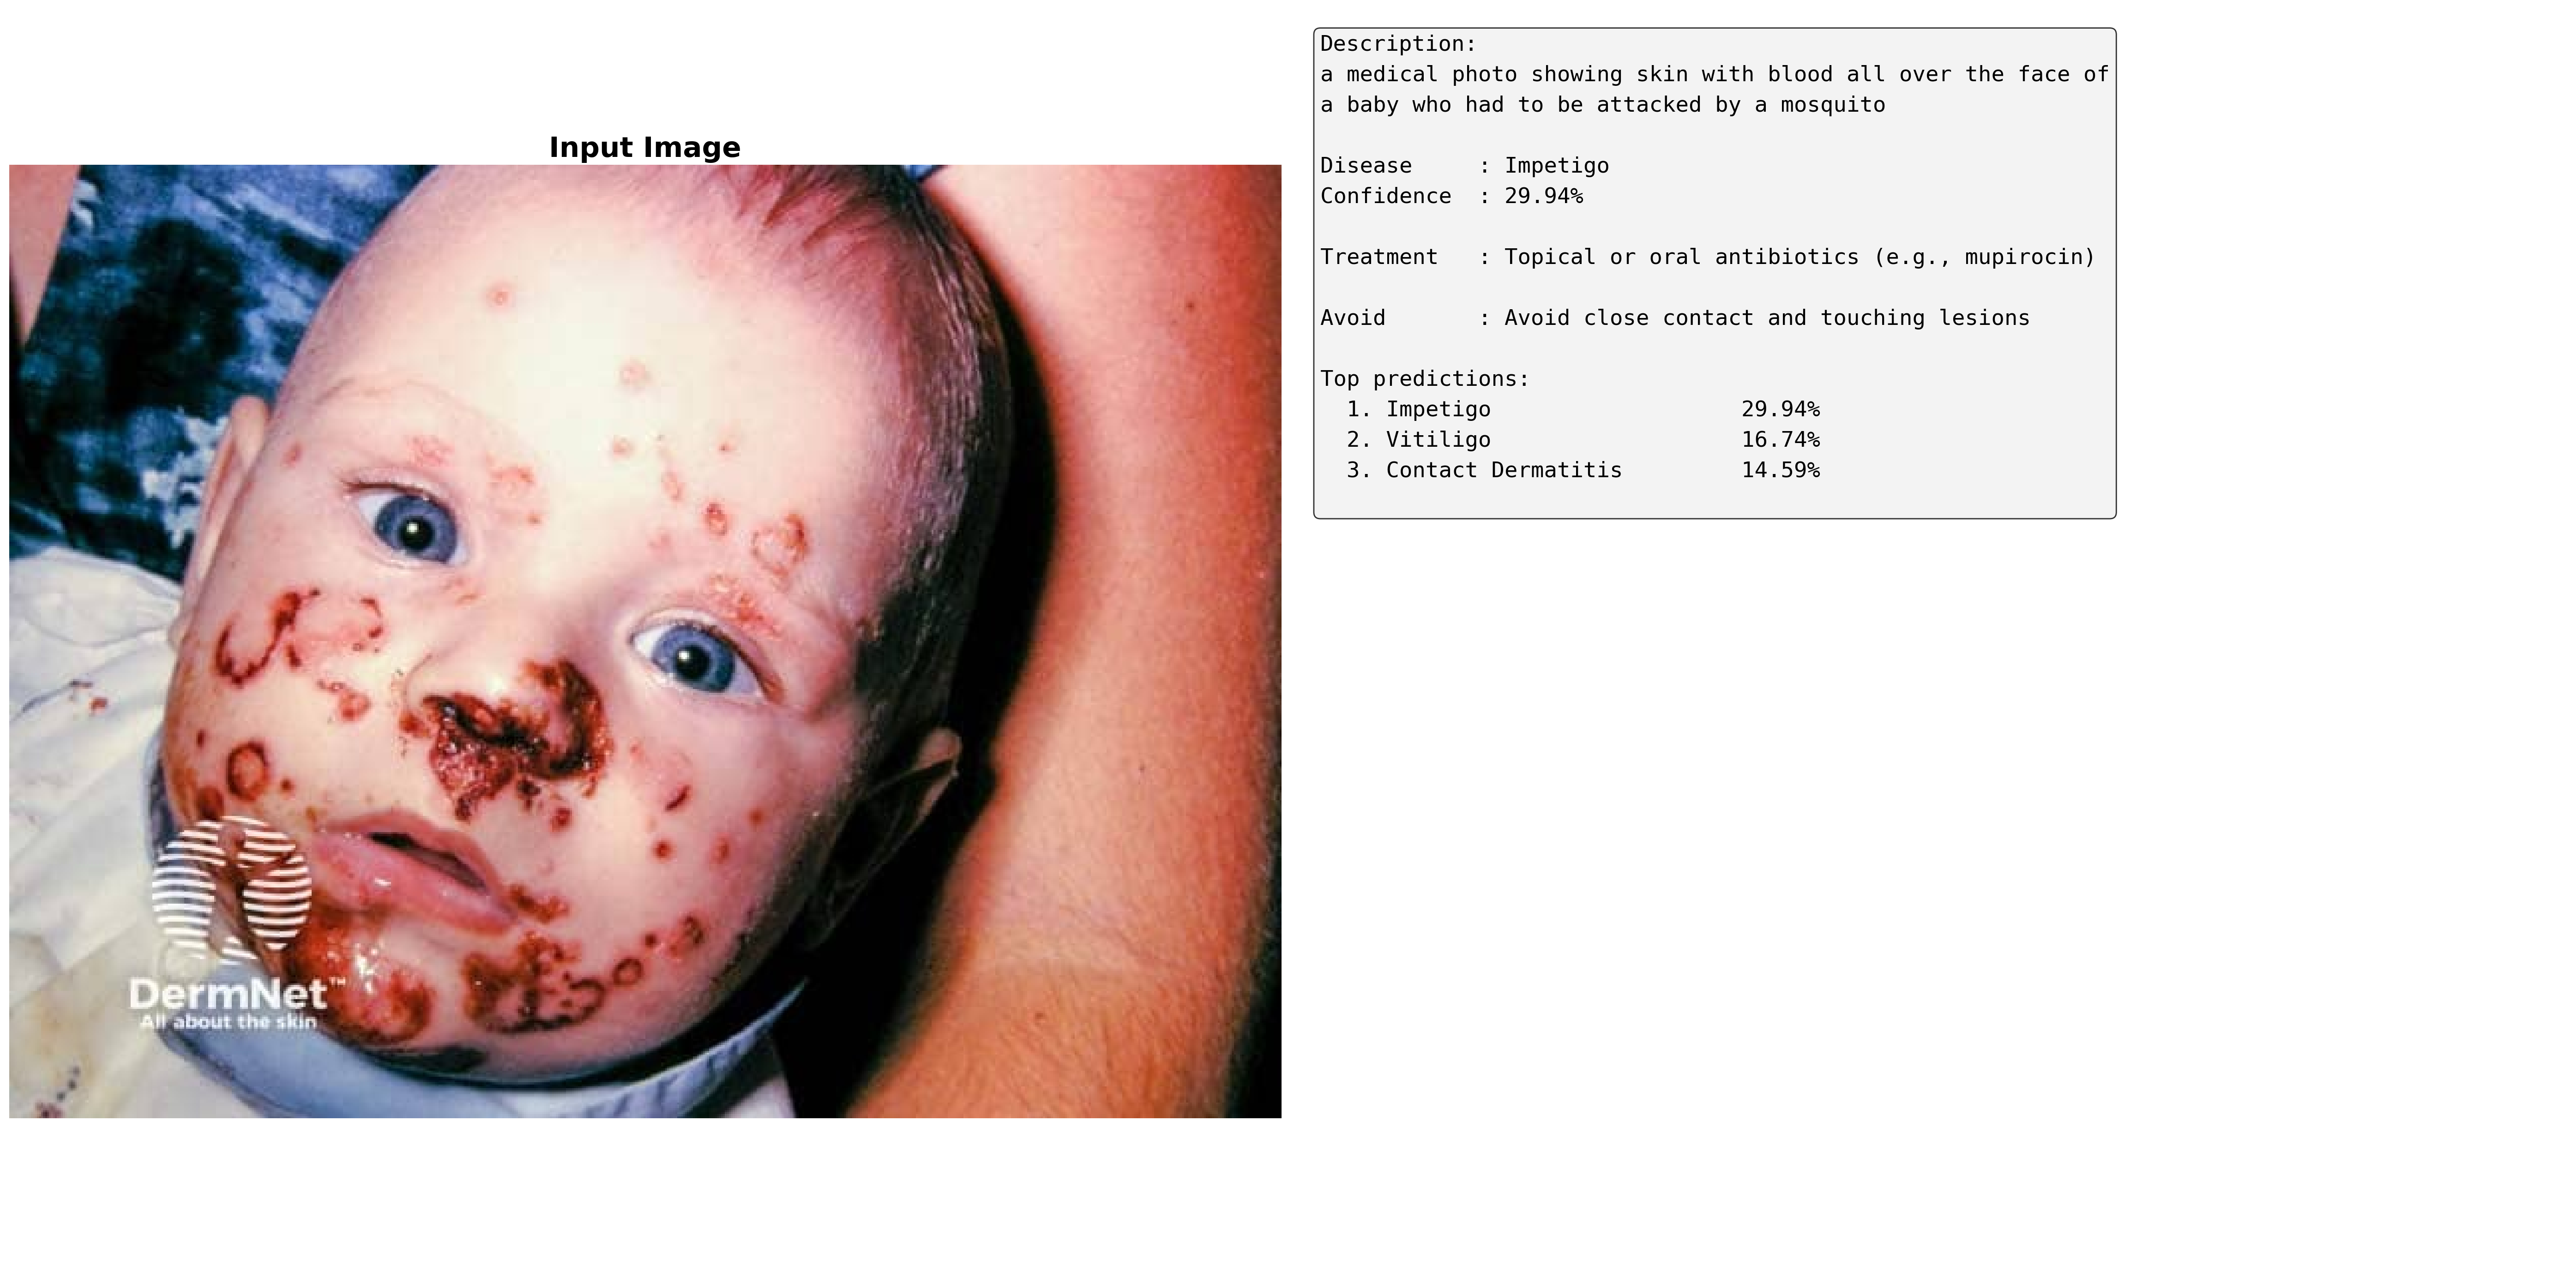

In [24]:
IMAGE_PATH = r'C:\Users\sandy\Downloads\Neural-Project-main\Neural-Project-main\dermnet_dataset\Impetigo\Impetigo_8.jpg'

if os.path.exists(IMAGE_PATH):
    result = predict(IMAGE_PATH)
    show_result(IMAGE_PATH, result)
else:
    print('Image not found:', IMAGE_PATH)

Generated description: a medical photo showing skin with this image highlights an extensive area of infection around the mouth, nose, and cheeks of an infant. the rash is characterized by widespread redness and numerous patches of confluent, amber - colored crusting. there are visible signs of fluid discharge ( exudate ) which then dries to form the characteristic scaly layers on the face. this more severe clinical picture often requires prompt topical or systemic antibiotic treatment to resolve. including


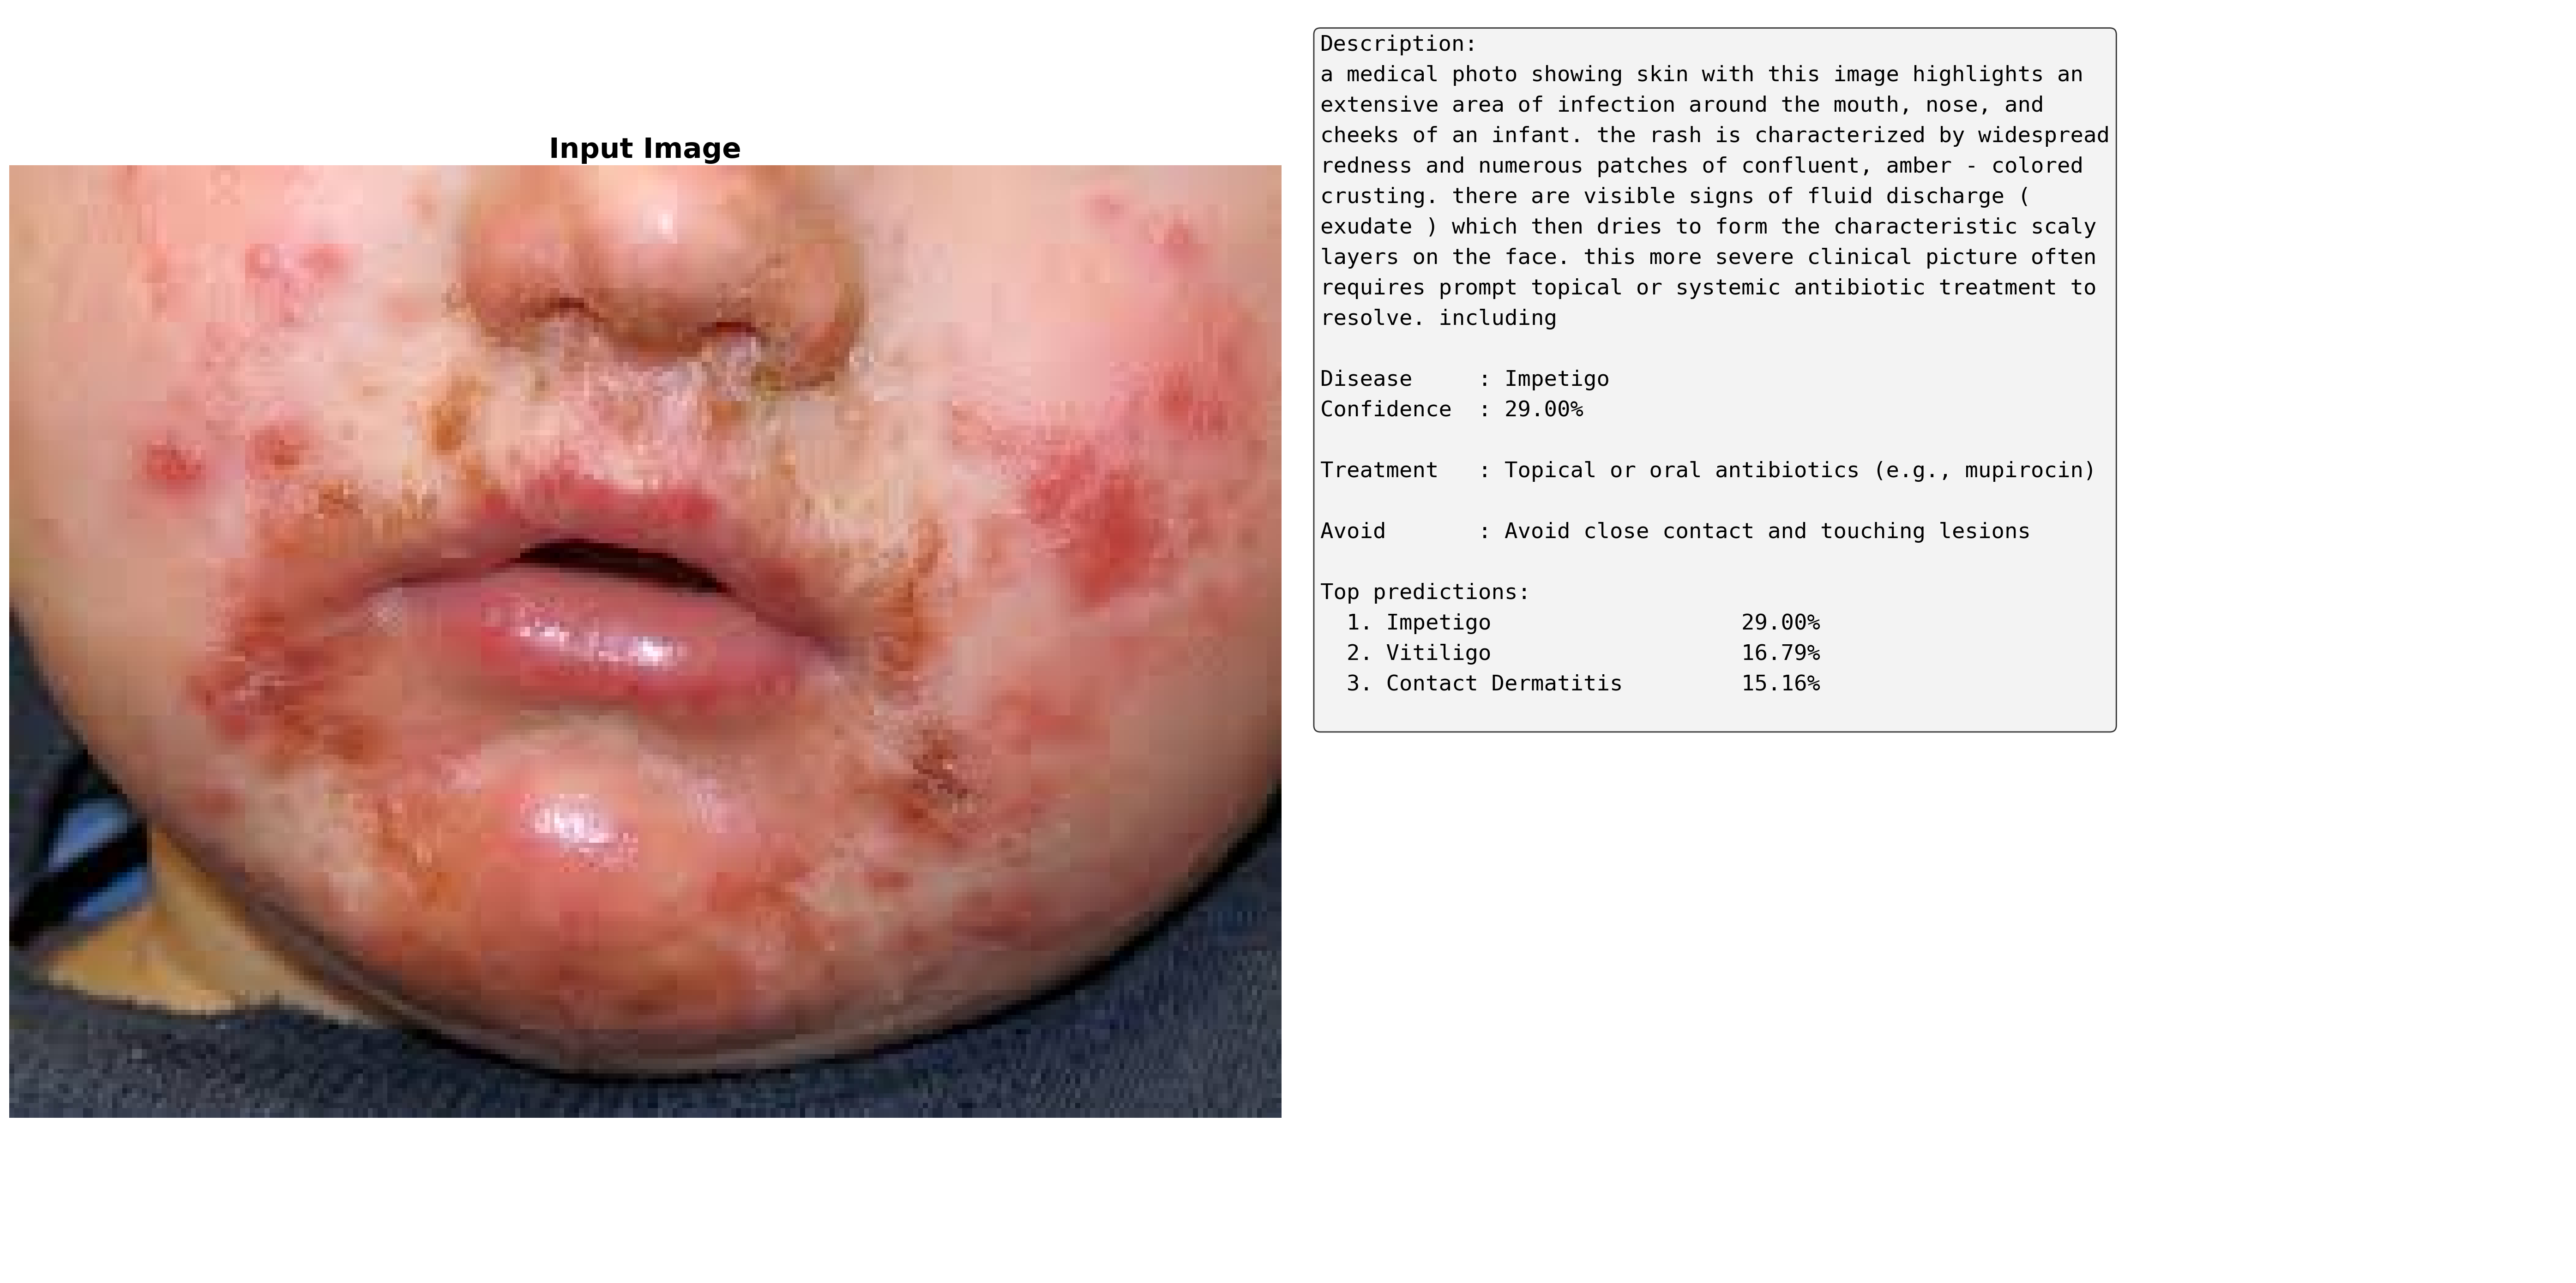

In [ ]:
while True:
    img_path = input('Image path (or quit): ').strip()
    if img_path.lower() in ('quit', 'exit', 'q'):
        break
    if not os.path.exists(img_path):
        print('Image not found.')
        continue

    user_desc = input('Description (leave empty to let BLIP generate automatically): ').strip()

    result = predict(img_path, user_description=user_desc if user_desc else None)
    show_result(img_path, result)